# Choosing a strongly correlated active space

Notebooks 1 and 2 answered *which orbitals belong to the fragment*. This one answers the next
question: given an embedded fragment, **which of its orbitals are worth handing to a correlated
solver**. Those are different jobs, and the split is worth keeping straight:

| module | question | consumed by |
|---|---|---|
| `nbed.act_env_space` | which orbitals are fragment, which are environment? | `EmbedSCF(...)` |
| `nbed.cas_space` | inside the fragment, which orbitals are actually correlated? | `get_mo_integrals(..., mo_cas_idxs=...)` |

## The trap this notebook exists to avoid

The obvious way to pick CAS orbitals is to reuse the criterion that picked the fragment: rank the
embedded virtuals by their Löwdin population on the target atoms. That criterion selects whatever
is **most localised** on those atoms, and in a polarised basis the winner is a bare $d$ shell on a
single atom sitting one to two hartree above the frontier. A CAS built from those orbitals is a
single determinant to three or four decimal places, so the correlated solver has nothing to do.

The population criterion is not *wrong*, it is answering a different question. "Sits on the target
atoms" and "is correlated" are unrelated properties.

## The pipeline

Two stages, neither of which ever allocates a quantity over the full virtual space:

```
embedded virtuals  ->  project onto the minimal valence AO space of the target atoms
                   ->  keep a bounded pool of the best-covered directions   (stage 1)
                   ->  MP2 inside [fragment occupied + pool]
                   ->  keep the natural orbitals furthest from 0 and 2      (stage 2)
```

Stage 1 finds the antibonding partners of the occupied fragment orbitals, which are the
$\sigma^*/\pi^*$ directions rather than polarisation functions. Stage 2 puts the polarisation
character back where correlation actually wants it, and gives a number per orbital that says how
much it matters. The cost is set by the pool size, not by the basis.

Stage 2 is deliberately thin. Once stage 1 has rotated the pool out of the virtual space, the pool
is an ordinary set of MO columns, so the MP2 is just

```python
mp.MP2(mf, frozen=everything_outside_the_pool).run()
```

and pyscf sizes the integral transform by the pool for us. That leaves stage 1 as the only real
content, and §8.2 checks it is earning its place: selecting the pool by orbital energy, which is
what `frozen` does unaided, is the natural way to skip stage 1 and it fails outright in a basis
with diffuse functions.

## Roadmap

1. Embed a fragment of methanol, with the C–O bond stretchable.
2. Show the population criterion picking correlation-free polarisation shells.
3. Rank the virtuals by fragment valence character instead.
4. Bounded pool, then MP2 natural orbitals. Check how big the pool has to be.
5. Ask whether the resulting CAS is *interesting*: unpaired electrons, orbital entanglement
   entropy, reference-determinant weight.
6. Stretch the C–O bond and watch the fragment turn into a diradical while the environment
   stays inert.
7. Four consistency checks: the level shift, whether stage 1 is necessary, a qubit Hamiltonian,
   and what does and does not guarantee orthogonality to the environment.

In [1]:
import nbed.backend
nbed.backend.set_backend(use_gpu=False)
if nbed.backend.USING_GPU:
    print("Running on GPU")
    import cupy as np
    from gpu4pyscf import dft, scf
    from pyscf import gto, lo, mcscf
else:
    print("Running on CPU")
    import numpy as np
    from pyscf import cc, ci, dft, gto, lo, mcscf, scf

np.set_printoptions(linewidth=110, suppress=True)
import numpy 

Running on CPU


In [2]:
from nbed.act_env_space import lowdin_populations, orbital_spread
from nbed.cas_space import (cas_columns_excluding_env, diagnose_cas,
                            fragment_valence_projector, report_cas_orbitals, run_casci,
                            select_cas_by_mp2_no, unpaired_electrons,
                            valence_virtual_rotation, von_neumann_entropy)
from nbed.emb_scf import EmbedSCF

## 1. The system

Methanol, with the C–O bond stretched along its own axis while both the methyl and hydroxyl groups
stay rigid. At equilibrium the fragment is unremarkable; stretched, it becomes
$\text{CH}_3\!\cdot$ + $\cdot\text{OH}$, a diradical that no single determinant describes.

The fragment is the $\{$O, C$\}$ pair, so the stretching bond lies inside it and the three C–H
bonds are environment. A polarised basis is deliberate: without $d$ functions the failure mode in
section 3 does not exist.

In [3]:
BASIS = "6-31G*"
XC = "b3lyp"
TARGETS = [0, 2]              # O and C, the atoms defining the fragment
N_OCC_FRAG, N_VIR_FRAG = 3, 4  # fragment size, fixing the embedded electron count at 6
N_CAS_VIR = 3                  # MP2 natural virtuals to make active
LAM = 1e6                      # huz_level_shift, see notebook 2
R_EQ, R_STRETCH = 1.40, 3.00    # R_EQ is the first point of the scan in section 7


def geometry(r):
    """Methanol with the C-O bond set to r Angstrom, both groups kept rigid."""
    o = numpy.array([-0.6582, -0.0067, 0.1730])
    c = numpy.array([0.7031, 0.0083, -0.1305])
    h_o = numpy.array([-1.1326, -0.0311, -0.6482])
    h_c = [numpy.array(x) for x in ([0.9877, 0.8943, -0.7114],
                                 [1.0155, -0.8918, -0.6742],
                                 [1.2001, 0.0363, 0.8431])]
    axis = (c - o) / numpy.linalg.norm(c - o)
    shift = axis * (r - numpy.linalg.norm(c - o))
    return [("O", o), ("H", h_o), ("C", c + shift)] + [("H", h + shift) for h in h_c]


native = np.linalg.norm(numpy.array([0.7031, 0.0083, -0.1305]) - numpy.array([-0.6582, -0.0067, 0.1730]))
print(f"the input geometry has C-O = {native:.3f} A; geometry(r) sets it explicitly,")
print(f"so this notebook works at r = {R_EQ} A (near equilibrium) and r = {R_STRETCH} A (stretched).")

the input geometry has C-O = 1.395 A; geometry(r) sets it explicitly,
so this notebook works at r = 1.4 A (near equilibrium) and r = 3.0 A (stretched).


## 2. Global DFT, localisation, fragment, embedding

Straight from notebook 1: localise inside occupation blocks, rank orbitals by target-atom
population, build the embedded HF. Two choices carried over deliberately:

- **Huzinaga with `huz_level_shift`.** Exact, and $\lambda$ parks the environment in the last
  columns so orbital windows behave. Section 8 shows what happens without it.
- **HF, not DFT, as the embedded reference.** MP2 perturbs a Hartree-Fock determinant, so the
  natural-orbital stage needs `build_emb_hf`.

In [4]:
def localise_blocks(mol, mf):
    """Pipek-Mezey within each occupation block, leaving the total density untouched."""
    if nbed.backend.USING_GPU:
        mo_coeff = mf.mo_coeff.get()
        mo_occ = mf.mo_occ.get()
        mf = mf.to_cpu()
    else:
        mo_coeff = mf.mo_coeff
        mo_occ = mf.mo_occ
    
    C = mo_coeff.copy()
    for mask in (mo_occ > 1, mo_occ == 1, mo_occ == 0):
        if mask.sum() > 1:
            C[:, mask] = lo.PipekMezey(mol, mo_coeff[:, mask]).kernel()
    assert np.allclose(mf.make_rdm1(mo_coeff=C, mo_occ=mo_occ),
                       mf.make_rdm1(mo_coeff=mo_coeff, mo_occ=mo_occ), atol=1e-9)
    return np.asarray(C)


def rank_by_population(mol, mf, C, n_occ, n_vir, max_spread=3.0):
    """Rank occupied and virtual orbitals separately by target-atom population."""
    _, pop = lowdin_populations(mol, C, TARGETS, drop_core_1s=True)
    ok = orbital_spread(mol, C) <= max_spread
    occ_pool = np.where((mf.mo_occ > 0) & ok)[0]
    vir_pool = np.where((mf.mo_occ == 0) & ok)[0]
    return (np.sort(occ_pool[np.argsort(-pop[occ_pool])[:n_occ]]),
            np.sort(vir_pool[np.argsort(-pop[vir_pool])[:n_vir]]))


def build_embedding(r, lam=LAM, follow=None, basis=None, proj="huz"):
    """Global DFT then embedded HF for one geometry.

    follow, when given, is the occupied fragment orbitals chosen at the previous geometry.
    The fragment is then picked by maximum overlap with those rather than by re-ranking, which
    matters along a scan: population ranking can swap a bonding orbital for a lone pair.
    """
    mol = gto.M(atom=geometry(r), basis=BASIS if basis is None else basis, verbose=0)
    glob = nbed.backend.pyscf.dft.RKS(mol, xc=XC)
    glob.verbose = 0
    glob.kernel()
    ovlp = glob.get_ovlp()
    C_loc = localise_blocks(mol, glob)

    pick_occ, pick_vir = rank_by_population(mol, glob, C_loc, N_OCC_FRAG, N_VIR_FRAG)
    tracking = 1.0
    if follow is not None:
        overlaps = np.abs(follow.T @ ovlp @ C_loc[:, glob.mo_occ > 0])
        occ_all = np.where(glob.mo_occ > 0)[0]
        chosen = []
        for row in range(overlaps.shape[0]):
            for j in np.argsort(-overlaps[row]):
                if occ_all[j] not in chosen:
                    chosen.append(occ_all[j])
                    break
        pick_occ = np.sort(np.array(chosen))
        tracking = overlaps.max(axis=1).min()

    active = np.concatenate([pick_occ, pick_vir])
    env = np.setdiff1d(np.arange(mol.nao), active)
    emb = EmbedSCF(glob, active, env, C_loc, glob.mo_occ, ovlp, 8000, mu_val=1e6)
    e_hf, mf, _, env_cols, env_plus_corr = emb.build_emb_hf(
        proj_type=proj, huz_level_shift=lam)

    return dict(mol=mol, glob=glob, ovlp=ovlp, emb=emb, mf=mf, env_cols=env_cols,
                env_plus_corr=env_plus_corr, e_hf=e_hf, pick_occ=pick_occ,
                C_frag_occ=C_loc[:, pick_occ].copy(), tracking=tracking,
                c_env_frozen=emb.C_full_reidx[:, emb.env_idx_occ].copy())

In [5]:
eq = build_embedding(R_EQ)
mf_eq, ovlp_eq, env_eq = eq["mf"], eq["ovlp"], eq["env_cols"]

print(f"global DFT            = {eq['glob'].e_tot:.8f} Ha")
print(f"HF-in-DFT             = {eq['e_hf']:.8f} Ha")
print(f"fragment              = {mf_eq.mol.nelectron} electrons, "
      f"{int((mf_eq.mo_occ > 0).sum())} occupied orbitals")
print(f"environment columns   = {env_eq}  (last columns, thanks to huz_level_shift)")

C_env = eq["emb"].C_full_reidx[:, eq["emb"].env_idx_occ]
overlap = np.abs(C_env.T @ ovlp_eq @ mf_eq.mo_coeff[:, mf_eq.mo_occ > 0]).max()
print(f"max |<env occ|S|emb occ>| = {overlap:.2e}   <- the embedding is clean")

global DFT            = -115.71118456 Ha
HF-in-DFT             = -115.42724570 Ha
fragment              = 6 electrons, 3 occupied orbitals
environment columns   = [30 31 32 33 34 35]  (last columns, thanks to huz_level_shift)
max |<env occ|S|emb occ>| = 1.23e-16   <- the embedding is clean


## 3. How the population criterion fails

Rank the environment-free virtuals by fragment population and look at what wins. Two extra columns
tell the story: the **valence weight**, meaning the fraction of the orbital lying in the minimal
valence space of O and C, and the orbital energy.

A genuine $\sigma^*(\text{C--O})$ has valence weight near one. A polarisation $d$ shell has valence
weight near zero, because a minimal basis has no $d$ function to overlap with.

In [6]:
vir_safe = np.setdiff1d(np.where(mf_eq.mo_occ == 0)[0], env_eq)
_, pop_emb = lowdin_populations(eq["mol"], mf_eq.mo_coeff, TARGETS)
p_ref, n_ref = fragment_valence_projector(eq["mol"], TARGETS)
valence_of = lambda cols: np.einsum(
    "ip,ij,jp->p", mf_eq.mo_coeff[:, cols], p_ref, mf_eq.mo_coeff[:, cols])

ranked = vir_safe[np.argsort(-pop_emb[vir_safe])]
print(f"minimal valence space of O+C has {n_ref} orbitals "
      f"(2s2p on each), out of {eq['mol'].nao} AOs\n")
print("  the 6 virtuals a population ranking would take first:")
print(f"  {'col':>5} {'fragment pop':>13} {'valence weight':>15} {'energy / Ha':>12} {'spread / Bohr':>14}")
for col in ranked[:6]:
    print(f"  {col:>5} {pop_emb[col]:>13.3f} {valence_of([col])[0]:>15.4f} "
          f"{mf_eq.mo_energy[col]:>12.3f} {orbital_spread(eq['mol'], mf_eq.mo_coeff[:, [col]])[0]:>14.2f}")

print("\n  every one scores ~1.0 on the fragment, which is why it wins,")
print("  yet the valence weight is ~0.01 and they sit 1-2 Ha above the frontier:")
print("  these are polarisation shells, and they correlate nothing.")

minimal valence space of O+C has 8 orbitals (2s2p on each), out of 36 AOs

  the 6 virtuals a population ranking would take first:
    col  fragment pop  valence weight  energy / Ha  spread / Bohr
     15         1.000          0.0083        1.242           2.22
     21         0.993          0.0114        1.924           2.27
     19         0.984          0.0023        1.766           2.00
     22         0.979          0.0005        2.027           1.71
     29         0.970          0.0023        3.162           2.17
     20         0.970          0.0070        1.802           2.20

  every one scores ~1.0 on the fragment, which is why it wins,
  yet the valence weight is ~0.01 and they sit 1-2 Ha above the frontier:
  these are polarisation shells, and they correlate nothing.


## 4. Ranking by fragment valence character instead

`valence_virtual_rotation` diagonalises the valence projector inside the virtual space. Each
eigenvalue is the fraction of that rotated virtual lying in the minimal valence space of the target
atoms, and the drop in the spectrum says how many virtuals are worth keeping.

In [7]:
_, weights, _ = valence_virtual_rotation(eq["mol"], mf_eq.mo_coeff[:, vir_safe], TARGETS)

print(f"valence weights of all {len(vir_safe)} environment-free virtuals:")
print(f"  {np.round(weights[:12], 4)} ...")
print(f"\nthey sum to {weights.sum():.3f}: the occupied fragment orbitals already hold")
print(f"most of the {n_ref}-dimensional valence space, and the virtuals get the antibonding rest.")
print(f"\nthe spectrum falls off a cliff after the first: {weights[0]:.3f} -> {weights[1]:.3f}")
print("so at equilibrium there is essentially one antibonding direction, the sigma*(C-O).")

valence weights of all 27 environment-free virtuals:
  [0.9892 0.1678 0.1581 0.0846 0.0599 0.0123 0.0041 0.002  0.     0.     0.     0.    ] ...

they sum to 1.478: the occupied fragment orbitals already hold
most of the 8-dimensional valence space, and the virtuals get the antibonding rest.

the spectrum falls off a cliff after the first: 0.989 -> 0.168
so at equilibrium there is essentially one antibonding direction, the sigma*(C-O).


## 5. Bounded pool, then MP2 natural orbitals

Valence weight says which virtuals are *shaped* right, not which are *correlated*. Stage 2 settles
that with an MP2 inside [fragment occupied + pool] and keeps the natural orbitals furthest from
zero occupation. The pool is what keeps this bounded: MP2 and the integral transform both scale
with `n_pool`, which defaults to `3 * N_CAS_VIR`, never with the size of the basis.

Mechanically the pool orbitals are written back into a copy of the mean field and everything else
is handed to pyscf's `frozen` keyword, so the truncation is pyscf's own frozen-orbital MP2. The one
subtlety is that stage 1's valence rotation leaves the pool non-canonical, and MP2 denominators are
orbital energy differences only when the Fock matrix is diagonal, so the pool is semicanonicalised
first. `select_cas_by_mp2_no` asserts both that and Fock stationarity before trusting the result.

The default pool of `3 * N_CAS_VIR = 9` exceeds the eight-dimensional valence space measured in §4,
so this cell emits a reproducibility warning. It is legitimate and §5.1 explains it; the short
version is that the ninth pool orbital is drawn from a null space where the ordering is round-off.

Run it at both geometries and compare.

In [8]:
stretched = build_embedding(R_STRETCH)

selections = {}
for label, sysd in (("equilibrium", eq), ("stretched", stretched)):
    sel = select_cas_by_mp2_no(sysd["mf"], TARGETS, n_cas_vir=N_CAS_VIR,
                               env_cols=sysd["env_cols"], ovlp=sysd["ovlp"])
    selections[label] = (sel, sysd)
    print(f"{label:>12}: CAS({sum(sel.nelecas)}e,{sel.ncas}o) from a pool of {sel.n_pool}; "
          f"MP2 natural occupations of the CAS virtuals {np.round(sel.cas_natural_occ, 4)}")
    print(f"{'':>12}  the pool tail, left out: {np.round(sel.pool_natural_occ[N_CAS_VIR:], 5)}")

 equilibrium: CAS(6e,6o) from a pool of 9; MP2 natural occupations of the CAS virtuals [0.015  0.0074 0.006 ]
              the pool tail, left out: [0.00144 0.00083 0.00013 0.00011 0.00007 0.00001]
   stretched: CAS(6e,6o) from a pool of 9; MP2 natural occupations of the CAS virtuals [0.276  0.0136 0.0086]
              the pool tail, left out: [0.00455 0.0011  0.0002  0.00008 0.00007 0.00003]


/var/folders/cr/lt00fp0j353b4t_4p9h1rww00000gn/T/ipykernel_22240/2006861579.py:5: UserWarning: the pool of 9 reaches past this fragment's valence space, which only spans 8 virtuals: orbitals 8 onwards have valence weight below 1e-06, so which of them the pool takes is set by round-off and the result is not reproducible to better than ~1e-4 Ha. Either drop n_pool to 8 or pass the whole environment-free virtual space (27), where the ordering stops mattering.
  sel = select_cas_by_mp2_no(sysd["mf"], TARGETS, n_cas_vir=N_CAS_VIR,


In [9]:
sel_s, _ = selections["stretched"]
c_cas = sel_s.c_full[:, sel_s.mo_cas_idxs]
rot = stretched["mf"].mo_coeff.T @ stretched["ovlp"] @ c_cas
e_cas = np.einsum("ip,i,iq->pq", rot, stretched["mf"].mo_energy, rot).diagonal()

# the valence projector is built from the AO basis, so it belongs to one geometry:
# reusing the equilibrium projector here would give weights above 1
p_ref_s, _ = fragment_valence_projector(stretched["mol"], TARGETS)

print(f"what ended up in the CAS at r = {R_STRETCH} A:\n")
print(report_cas_orbitals(stretched["mol"], c_cas, TARGETS, len(sel_s.cas_occ_cols),
                          mo_energy=e_cas, p_ref=p_ref_s, occ_no=sel_s.cas_natural_occ))
print("\ncolumn 3 is the one that matters: valence weight ~1, MP2 occupation 0.28,")
print("and it straddles both atoms. That is the sigma*(C-O). Compare its energy with the")
print("1-2 Ha of the population-ranked virtuals in section 3.")

what ended up in the CAS at r = 3.0 A:

    idx  occ    energy  fragpop  valence  spread   MP2 nat occ   composition
      0  2.0   -0.8596    0.975    0.987    1.27                O0:0.97
      1  2.0   -0.4207    1.000    0.996    1.46                O0:1.00
      2  2.0   -0.3116    0.992    0.983    2.93                O0:0.65 C2:0.34
      3  0.0   -0.0212    0.984    0.987    3.04      0.27599   O0:0.37 C2:0.62
      4  0.0    1.3402    0.993    0.004    2.07      0.01359   O0:0.98
      5  0.0    0.9877    0.746    0.018    2.74      0.00861   O0:0.71
    fragment population: occupied min 0.975, virtual min 0.746 mean 0.908; virtual valence weight 1.01

column 3 is the one that matters: valence weight ~1, MP2 occupation 0.28,
and it straddles both atoms. That is the sigma*(C-O). Compare its energy with the
1-2 Ha of the population-ranked virtuals in section 3.


### 5.1 How big does the pool have to be?

The pool is the one knob with a cost attached, so it is worth knowing where it saturates. The right
thing to watch is not the MP2 correlation energy inside the pool, which necessarily grows as the
pool grows, but whether the *selected CAS* stops changing.

`select_cas_by_mp2_no` warns for the middle rows here, and the warning is worth reading rather than
suppressing. The valence projector has the rank of the fragment's minimal valence space — 8 for
O+C — so from §4 the weights past the eighth virtual are exactly zero, at $10^{-15}$. A pool larger
than 8 therefore takes its extra orbitals from a degenerate null space, where the ordering is
round-off rather than physics. Those extras still *help*, which is why the table below keeps
improving; what they cost is reproducibility, at the $10^{-4}$ Ha level, between embeddings that
should be identical. The clean choices are a pool inside the valence block or the whole virtual
space, and the last row is the latter.

In [10]:
n_vir_safe = len(np.setdiff1d(np.where(stretched["mf"].mo_occ == 0)[0], stretched["env_cols"]))
print(f"r = {R_STRETCH} A, {n_vir_safe} environment-free virtuals available\n")
print(f"  {'n_pool':>7} {'multiple':>9} {'top NO occ':>11} {'E(CASCI)':>13} {'N_unpaired':>11} {'vs full pool':>13}")

pool_rows = {}
for n_pool in (3, 6, 9, 12, 18, n_vir_safe):
    sel = select_cas_by_mp2_no(stretched["mf"], TARGETS, n_cas_vir=N_CAS_VIR, n_pool=n_pool,
                               env_cols=stretched["env_cols"], ovlp=stretched["ovlp"])
    diag = diagnose_cas(run_casci(stretched["mf"], sel.ncas, sel.nelecas,
                                  mo_coeff=sel.c_full, mo_cas_idxs=sel.mo_cas_idxs),
                        verbose=False)
    pool_rows[n_pool] = (sel.cas_natural_occ[0], diag.e_tot, diag.n_unpaired)

full = pool_rows[n_vir_safe][1]
for n_pool, (no, e_tot, n_u) in pool_rows.items():
    print(f"  {n_pool:>7} {n_pool / N_CAS_VIR:>8.0f}x {no:>11.5f} {e_tot:>13.6f} "
          f"{n_u:>11.4f} {1000 * (e_tot - full):>+10.2f} mHa")

print(f"\nAt 3x the CAS virtual count the CAS is within "
      f"{1000 * abs(pool_rows[9][1] - full):.1f} mHa of the unrestricted {n_vir_safe}-orbital pool,")
print(f"against {1000 * abs(pool_rows[3][1] - full):.1f} mHa at 1x. Note the n_pool = 6 row, where")
print(f"N_unpaired jumps to {pool_rows[6][2]:.2f}: too small a pool does not merely lose accuracy,")
print("it can select a qualitatively different active space. Do not economise below about 3x.")

r = 3.0 A, 27 environment-free virtuals available

   n_pool  multiple  top NO occ      E(CASCI)  N_unpaired  vs full pool


/var/folders/cr/lt00fp0j353b4t_4p9h1rww00000gn/T/ipykernel_22240/4049105505.py:7: UserWarning: the pool of 9 reaches past this fragment's valence space, which only spans 8 virtuals: orbitals 8 onwards have valence weight below 1e-06, so which of them the pool takes is set by round-off and the result is not reproducible to better than ~1e-4 Ha. Either drop n_pool to 8 or pass the whole environment-free virtual space (27), where the ordering stops mattering.
  sel = select_cas_by_mp2_no(stretched["mf"], TARGETS, n_cas_vir=N_CAS_VIR, n_pool=n_pool,
/var/folders/cr/lt00fp0j353b4t_4p9h1rww00000gn/T/ipykernel_22240/4049105505.py:7: UserWarning: the pool of 12 reaches past this fragment's valence space, which only spans 8 virtuals: orbitals 8 onwards have valence weight below 1e-06, so which of them the pool takes is set by round-off and the result is not reproducible to better than ~1e-4 Ha. Either drop n_pool to 8 or pass the whole environment-free virtual space (27), where the ordering sto

        3        1x     0.25264     15.476165      1.2505     +39.73 mHa
        6        2x     0.26691     15.451127      2.0127     +14.69 mHa
        9        3x     0.27599     15.445559      1.2383      +9.13 mHa
       12        4x     0.27532     15.446035      1.2191      +9.60 mHa
       18        6x     0.27840     15.444842      1.2076      +8.41 mHa
       27        9x     0.28303     15.436433      1.1970      +0.00 mHa

At 3x the CAS virtual count the CAS is within 9.1 mHa of the unrestricted 27-orbital pool,
against 39.7 mHa at 1x. Note the n_pool = 6 row, where
N_unpaired jumps to 2.01: too small a pool does not merely lose accuracy,
it can select a qualitatively different active space. Do not economise below about 3x.


## 6. Is the CAS actually interesting?

Four measures, cheapest first.

- **MP2 natural occupations** come free from the selection. Available before any CASCI, so this is
  the one to screen with.
- **Effectively unpaired electrons** $N_u = \sum_i \min(n_i, 2-n_i)$ is zero for a closed-shell
  determinant and two for a perfect diradical.
- **Orbital entanglement entropy** is the DMRG-style measure. Each spatial orbital has four local
  states (empty, up, down, doubly occupied) whose probabilities follow from the spin-resolved
  CASCI density matrices; an orbital cleanly empty or cleanly full contributes nothing. For a
  dissociating pair each of the two partners tends to $\ln 2 \approx 0.693$.
- **Reference weight** $1 - c_0^2$ is how much of the wavefunction is not the aufbau determinant.

Run all of them on the MP2-selected CAS and on a population-ranked CAS of *identical size*.

In [11]:
def population_ranked_cas(sysd, n_vir):
    """The CAS a naive fragment-population ranking would pick, same size as the MP2 one."""
    mf, env_cols = sysd["mf"], sysd["env_cols"]
    _, pop = lowdin_populations(sysd["mol"], mf.mo_coeff, TARGETS)
    safe = np.setdiff1d(np.where(mf.mo_occ == 0)[0], env_cols)
    occ_cols = np.where(mf.mo_occ > 0)[0]
    pick = np.sort(safe[np.argsort(-pop[safe])[:n_vir]])
    return np.concatenate([occ_cols, pick]), (len(occ_cols), len(occ_cols))


for label in ("equilibrium", "stretched"):
    sel, sysd = selections[label]
    print("=" * 78)
    print(f"{label}   (r = {R_EQ if label == 'equilibrium' else R_STRETCH} A)")
    print("=" * 78)
    print(f"  cheap screen, no CASCI: entropy of the MP2 virtual occupations = "
          f"{von_neumann_entropy(sel.cas_natural_occ):.4f} nats")
    print("\n  MP2 natural-orbital CAS:")
    d_mp2 = diagnose_cas(run_casci(sysd["mf"], sel.ncas, sel.nelecas,
                                   mo_coeff=sel.c_full, mo_cas_idxs=sel.mo_cas_idxs))
    idxs, nelecas = population_ranked_cas(sysd, N_CAS_VIR)
    print("\n  population-ranked CAS, same size:")
    d_pop = diagnose_cas(run_casci(sysd["mf"], len(idxs), nelecas, mo_cas_idxs=idxs))
    print(f"\n  --> MP2 selection recovers {d_pop.e_tot - d_mp2.e_tot:+.6f} Ha more correlation, "
          f"with N_unpaired {d_mp2.n_unpaired:.4f} against {d_pop.n_unpaired:.4f}\n")

equilibrium   (r = 1.4 A)
  cheap screen, no CASCI: entropy of the MP2 virtual occupations = 0.0888 nats

  MP2 natural-orbital CAS:
  CASCI energy of the subsystem : 26.62899275 Ha
  natural occupations           : [1.9928 1.9913 1.9771 0.0231 0.0086 0.0071]
  effectively unpaired electrons: 0.0777   (nonlinear 0.0052)
  entropy of the occupations    : 0.2291 nats
  aufbau determinant weight     : 0.9805   so 1 - c0^2 = 0.0195
  largest determinant weight    : 0.9805
  summed orbital entropy        : 0.3774 nats
  per-orbital entropy           : [0.0606 0.0851 0.0511 0.0895 0.0508 0.0402]
  verdict                       : essentially a single determinant

  population-ranked CAS, same size:
  CASCI energy of the subsystem : 26.66465581 Ha
  natural occupations           : [1.9993 1.999  1.9923 0.007  0.0016 0.0007]
  effectively unpaired electrons: 0.0187   (nonlinear 0.0004)
  entropy of the occupations    : 0.0655 nats
  aufbau determinant weight     : 0.9953   so 1 - c0^2 = 0.0047


The stretched case is the point of the whole notebook. Both CASs have the same size and the same
electron count, and both are built from orbitals that are 99% localised on O and C. One of them
finds a diradical with two orbitals at $\sim$1.4 and $\sim$0.6 electrons and per-orbital entropies
near 0.78; the other is a single determinant to three decimal places and would have been reported
as a perfectly respectable CASCI.

## 7. Stretching the bond

Now the scan. At each geometry: global DFT, embed, select the CAS by MP2 natural occupation, solve
it, and measure. The fragment orbitals are tracked by overlap from the previous geometry rather
than re-ranked, because a population ranking swaps the C–O bonding orbital for an oxygen lone pair
somewhere past 3 Å and the diradical then silently leaves the fragment.

In [12]:
radii = np.arange(1.4, 3.61, 0.2)
scan = []
follow = None

for r in radii:
    sysd = build_embedding(r, follow=follow)
    follow = sysd["C_frag_occ"]
    sel = select_cas_by_mp2_no(sysd["mf"], TARGETS, n_cas_vir=N_CAS_VIR,
                               env_cols=sysd["env_cols"], ovlp=sysd["ovlp"])
    diag = diagnose_cas(run_casci(sysd["mf"], sel.ncas, sel.nelecas,
                                  mo_coeff=sel.c_full, mo_cas_idxs=sel.mo_cas_idxs),
                        verbose=False)
    idxs, nelecas = population_ranked_cas(sysd, N_CAS_VIR)
    diag_pop = diagnose_cas(run_casci(sysd["mf"], len(idxs), nelecas, mo_cas_idxs=idxs),
                            verbose=False)
    scan.append(dict(r=r, tracking=sysd["tracking"], mp2_no=sel.cas_natural_occ[0],
                     n_unpaired=diag.n_unpaired, entropy=diag.entropy_total,
                     non_reference=1 - diag.reference_weight, e_cas=diag.e_tot,
                     e_cas_in_dft=diag.e_tot + sysd["env_plus_corr"],
                     n_unpaired_pop=diag_pop.n_unpaired,
                     occ_hi=diag.natural_occ[2], occ_lo=diag.natural_occ[3]))

print(f"  {'r / A':>6} {'track':>6} {'MP2 NO':>8} {'n_HONO':>7} {'n_LUNO':>7} "
      f"{'N_unp':>7} {'S_orb':>7} {'1-c0^2':>7} | {'N_unp (pop)':>11}")
for row in scan:
    print(f"  {row['r']:>6.1f} {row['tracking']:>6.2f} {row['mp2_no']:>8.4f} "
          f"{row['occ_hi']:>7.4f} {row['occ_lo']:>7.4f} {row['n_unpaired']:>7.4f} "
          f"{row['entropy']:>7.4f} {row['non_reference']:>7.4f} | {row['n_unpaired_pop']:>11.4f}")

/var/folders/cr/lt00fp0j353b4t_4p9h1rww00000gn/T/ipykernel_22240/2461942622.py:8: UserWarning: the pool of 9 reaches past this fragment's valence space, which only spans 8 virtuals: orbitals 8 onwards have valence weight below 1e-06, so which of them the pool takes is set by round-off and the result is not reproducible to better than ~1e-4 Ha. Either drop n_pool to 8 or pass the whole environment-free virtual space (27), where the ordering stops mattering.
  sel = select_cas_by_mp2_no(sysd["mf"], TARGETS, n_cas_vir=N_CAS_VIR,


   r / A  track   MP2 NO  n_HONO  n_LUNO   N_unp   S_orb  1-c0^2 | N_unp (pop)
     1.4   1.00   0.0150  1.9771  0.0231  0.0777  0.3774  0.0195 |      0.0187
     1.6   0.71   0.0238  1.9566  0.0437  0.1281  0.5435  0.0321 |      0.0052
     1.8   0.71   0.0355  1.9233  0.0769  0.2114  0.7474  0.0532 |      0.0039
     2.0   0.97   0.0528  1.8737  0.1265  0.3109  0.9057  0.0789 |      0.0030
     2.2   0.98   0.0757  1.8008  0.1994  0.4545  1.0865  0.1171 |      0.0021
     2.4   0.98   0.1060  1.7077  0.2925  0.6382  1.2867  0.1671 |      0.0020
     2.6   0.98   0.1458  1.6014  0.3988  0.8486  1.5097  0.2264 |      0.0020
     2.8   0.98   0.1974  1.4988  0.5014  1.0520  1.6893  0.2831 |      0.0020
     3.0   0.99   0.2654  1.3984  0.6019  1.2520  1.8596  0.3400 |      0.0032
     3.2   0.99   0.3498  1.3129  0.6873  1.4212  1.9780  0.3875 |      0.0032
     3.4   0.99   0.4588  1.2361  0.7639  1.5736  2.0795  0.4309 |      0.0060
     3.6   0.99   0.5950  1.1599  0.8395  1.7232  2.

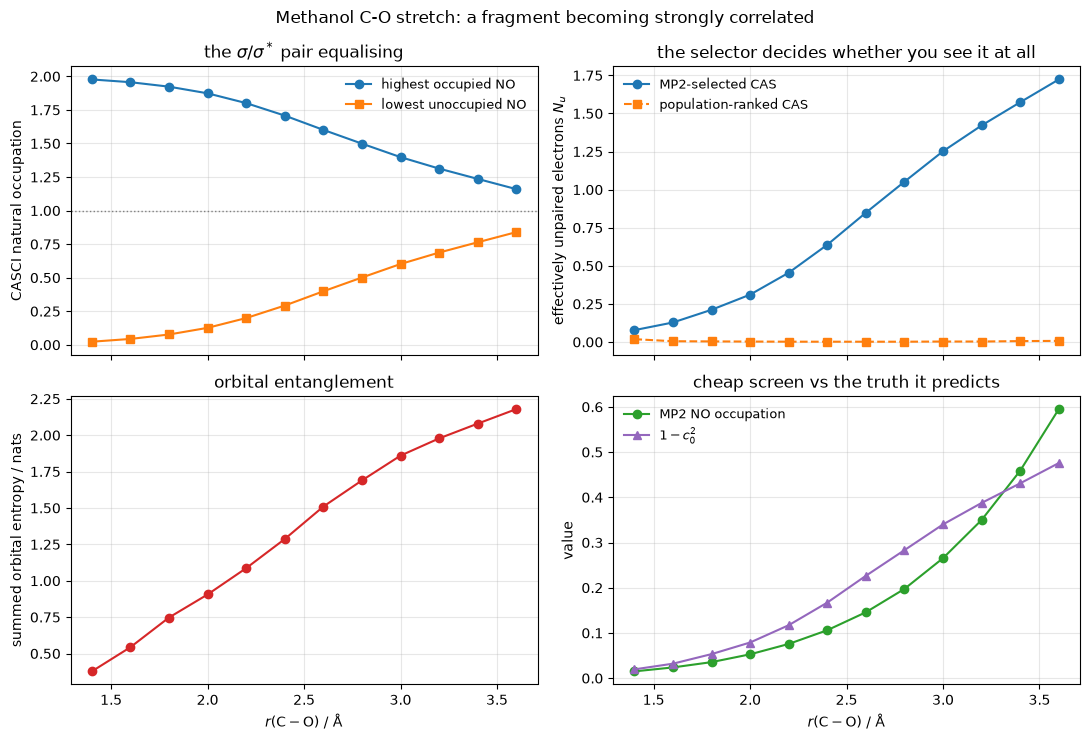

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

r = np.array([row["r"] for row in scan])
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)

ax = axes[0, 0]
ax.plot(r, [row["occ_hi"] for row in scan], "o-", label="highest occupied NO")
ax.plot(r, [row["occ_lo"] for row in scan], "s-", label="lowest unoccupied NO")
ax.axhline(1.0, color="grey", ls=":", lw=1)
ax.set_ylabel("CASCI natural occupation")
ax.set_title("the $\\sigma/\\sigma^*$ pair equalising")
ax.legend(frameon=False, fontsize=9)

ax = axes[0, 1]
ax.plot(r, [row["n_unpaired"] for row in scan], "o-", label="MP2-selected CAS")
ax.plot(r, [row["n_unpaired_pop"] for row in scan], "s--", label="population-ranked CAS")
ax.set_ylabel("effectively unpaired electrons $N_u$")
ax.set_title("the selector decides whether you see it at all")
ax.legend(frameon=False, fontsize=9)

ax = axes[1, 0]
ax.plot(r, [row["entropy"] for row in scan], "o-", color="tab:red")
ax.set_ylabel("summed orbital entropy / nats")
ax.set_xlabel(r"$r(\mathrm{C-O})$ / $\mathrm{\AA}$")
ax.set_title("orbital entanglement")

ax = axes[1, 1]
ax.plot(r, [row["mp2_no"] for row in scan], "o-", color="tab:green", label="MP2 NO occupation")
ax.plot(r, [row["non_reference"] for row in scan], "^-", color="tab:purple", label="$1-c_0^2$")
ax.set_ylabel("value")
ax.set_xlabel(r"$r(\mathrm{C-O})$ / $\mathrm{\AA}$")
ax.set_title("cheap screen vs the truth it predicts")
ax.legend(frameon=False, fontsize=9)

for ax in axes.ravel():
    ax.grid(alpha=0.3)
fig.suptitle("Methanol C-O stretch: a fragment becoming strongly correlated", fontsize=12)
fig.tight_layout()
plt.show()

Every measure rises monotonically and they agree with each other, which is the useful part: the
MP2 natural occupation in the bottom-right panel costs one MP2 inside a nine-orbital pool, and it
tracks $1-c_0^2$, a quantity you can only get after solving the CAS. That is what makes it usable
as a screen on systems too large to solve first.

The population-ranked curve in the top-right panel stays flat on the floor across the entire scan.
It is not noisy or approximate, it is blind.

## 8. Three consistency checks

### 8.1 Without `huz_level_shift`, the contiguous CAS window collides with the environment

Plain Huzinaga shifts each environment orbital by only $|\varepsilon_\text{env}|$, so they scatter
among the fragment virtuals instead of landing at the end. `mcscf.CASCI` takes a contiguous window
and will quietly swallow one. `cas_columns_excluding_env` picks by role instead.

In [14]:
plain = build_embedding(R_STRETCH, lam=0.0)
idxs, nelecas, window, collision = cas_columns_excluding_env(
    plain["mf"].mo_occ, plain["env_cols"], 2, 3, plain["mf"].mol.nelectron)

print(f"plain huz (lambda = 0), environment columns : {plain['env_cols']}")
print(f"contiguous window CASCI would have taken    : {window}")
print(f"environment orbitals inside that window     : {collision}"
      f"  {'<-- would be silently wrong' if len(collision) else '(none this time)'}")
print(f"role-selected columns instead               : {idxs}")

plain huz (lambda = 0), environment columns : [ 5  6 10 11 34 35]
contiguous window CASCI would have taken    : [1 2 3 4 5]
environment orbitals inside that window     : [5]  <-- would be silently wrong
role-selected columns instead               : [1 2 3 4 7]


### 8.2 Why the pool is not just `frozen` with the lowest virtuals

Stage 2 is nothing more than `mp.MP2(mf, frozen=everything_outside_the_pool)`, so a fair question is
whether stage 1 is needed at all. pyscf's `frozen` keyword selects orbitals by **column index**,
which for a converged mean field means by orbital energy, so the cheap alternative is "keep the $N$
lowest virtuals and freeze the rest". No projector, no rotation.

That works whenever the interesting antibonding orbital happens to be the lowest virtual, which for
a badly stretched bond it is. It fails as soon as the basis carries diffuse functions, because then
the lowest virtuals are Rydberg-like: spatially huge, energetically low, and correlating nothing.
Ranking by valence character is immune to this, since a diffuse function has almost no overlap with
a minimal basis.

Compare the two at a fixed pool size, in a basis with diffuse functions.

In [17]:
def cas_by_lowest_virtuals(sysd, n_pool, n_cas_vir):
    """The `frozen`-only alternative: keep the n_pool lowest virtuals, freeze the rest."""
    mf, env_cols = sysd["mf"], sysd["env_cols"]
    occ_cols = np.where(mf.mo_occ > 0)[0]
    safe = np.setdiff1d(np.where(mf.mo_occ == 0)[0], env_cols)
    keep = safe[np.argsort(mf.mo_energy[safe])[:n_pool]]
    frozen = np.setdiff1d(np.arange(mf.mo_coeff.shape[1]), np.concatenate([occ_cols, keep]))

    pt = nbed.backend.pyscf.mp.MP2(mf, frozen=[int(i) for i in frozen])
    pt.verbose = 0
    pt.kernel()
    occs, vecs = np.linalg.eigh(pt.make_rdm1()[np.ix_(keep, keep)])
    order = np.argsort(-occs)

    c_full = mf.mo_coeff.copy()
    c_full[:, keep] = mf.mo_coeff[:, keep] @ vecs[:, order]
    idxs = np.concatenate([occ_cols, keep[:n_cas_vir]])
    return c_full, idxs, (len(occ_cols), len(occ_cols)), occs[order], keep


N_POOL_TEST = 6
for basis in ("6-31G*", "aug-cc-pVDZ"):
    sysd = build_embedding(R_EQ, basis=basis)
    mf_b, env_b = sysd["mf"], sysd["env_cols"]
    safe_b = np.setdiff1d(np.where(mf_b.mo_occ == 0)[0], env_b)
    p_ref_b, _ = fragment_valence_projector(mf_b.mol, TARGETS)

    c_e, idx_e, nel_e, no_e, keep_e = cas_by_lowest_virtuals(sysd, N_POOL_TEST, N_CAS_VIR)
    d_e = diagnose_cas(run_casci(mf_b, len(idx_e), nel_e, mo_coeff=c_e, mo_cas_idxs=idx_e),
                       verbose=False)
    sel_v = select_cas_by_mp2_no(mf_b, TARGETS, n_cas_vir=N_CAS_VIR, n_pool=N_POOL_TEST,
                                 env_cols=env_b, ovlp=sysd["ovlp"])
    d_v = diagnose_cas(run_casci(mf_b, sel_v.ncas, sel_v.nelecas, mo_coeff=sel_v.c_full,
                                 mo_cas_idxs=sel_v.mo_cas_idxs), verbose=False)
    sel_all = select_cas_by_mp2_no(mf_b, TARGETS, n_cas_vir=N_CAS_VIR, n_pool=len(safe_b),
                                   env_cols=env_b, ovlp=sysd["ovlp"])
    d_all = diagnose_cas(run_casci(mf_b, sel_all.ncas, sel_all.nelecas,
                                   mo_coeff=sel_all.c_full,
                                   mo_cas_idxs=sel_all.mo_cas_idxs), verbose=False)

    val_low = np.einsum("ip,ij,jp->p", mf_b.mo_coeff[:, keep_e], p_ref_b,
                        mf_b.mo_coeff[:, keep_e])
    print(f"{basis}, r = {R_EQ} A, {len(safe_b)} environment-free virtuals, pool = {N_POOL_TEST}")
    print(f"  valence weight of the {N_POOL_TEST} lowest virtuals: {np.round(val_low, 4)}")
    print(f"    lowest-energy pool  : top MP2 NO {no_e[0]:.5f}   N_unpaired {d_e.n_unpaired:.4f}")
    print(f"    valence pool        : top MP2 NO {sel_v.cas_natural_occ[0]:.5f}   "
          f"N_unpaired {d_v.n_unpaired:.4f}")
    print(f"    no truncation at all: top MP2 NO {sel_all.cas_natural_occ[0]:.5f}   "
          f"N_unpaired {d_all.n_unpaired:.4f}   <- the target\n")

6-31G*, r = 1.4 A, 27 environment-free virtuals, pool = 6
  valence weight of the 6 lowest virtuals: [0.1514 0.0629 0.1073 0.0739 0.4428 0.1322]
    lowest-energy pool  : top MP2 NO 0.00458   N_unpaired 0.0175
    valence pool        : top MP2 NO 0.01200   N_unpaired 0.0551
    no truncation at all: top MP2 NO 0.01848   N_unpaired 0.1023   <- the target

aug-cc-pVDZ, r = 1.4 A, 73 environment-free virtuals, pool = 6
  valence weight of the 6 lowest virtuals: [0.003  0.0136 0.0005 0.0107 0.0544 0.0074]
    lowest-energy pool  : top MP2 NO 0.00002   N_unpaired 0.0000
    valence pool        : top MP2 NO 0.01220   N_unpaired 0.0568
    no truncation at all: top MP2 NO 0.01937   N_unpaired 0.1096   <- the target



### 8.3 The selected CAS as a qubit Hamiltonian

The selection hands back a full orbital set and a column list, which is exactly what
`get_mo_integrals` wants, so it drops into the notebook 1 pipeline unchanged. Exact
diagonalisation must reproduce CASCI-in-DFT.

In [ ]:
from nbed.hamiltonian import build_molecular_H, build_number_operator, build_spin_integrals
from openfermion import get_sparse_operator
from scipy.sparse.linalg import eigsh

mf_s = stretched["mf"]
cas_direct = run_casci(mf_s, sel_s.ncas, sel_s.nelecas,
                       mo_coeff=sel_s.c_full, mo_cas_idxs=sel_s.mo_cas_idxs)

ecore, h1e, eri = stretched["emb"].get_mo_integrals(
    mf_s, sel_s.c_full, sel_s.ncas, sel_s.nelecas, mo_cas_idxs=sel_s.mo_cas_idxs)
h1e_spin, eri_spin = build_spin_integrals(h1e, eri, sel_s.ncas)
nqubits = 2 * sel_s.ncas
assert nqubits <= 12, f"{nqubits} qubits is too many for dense diagonalisation"

Hq = build_molecular_H(stretched["env_plus_corr"] + ecore, h1e_spin, eri_spin)
Na, Nb = build_number_operator(nqubits, type="qubit_jw")
H_sym = Hq + (Na - sel_s.nelecas[0]) ** 2 + (Nb - sel_s.nelecas[1]) ** 2
eigvals = eigsh(get_sparse_operator(H_sym).real, k=3, which="SA")[0]

e_casci_in_dft = cas_direct.e_tot + stretched["env_plus_corr"]
print(f"{nqubits} qubits, {len(Hq.terms)} Pauli terms")
print(f"qubit ground state = {eigvals[0]:.10f}")
print(f"CASCI-in-DFT       = {e_casci_in_dft:.10f}")
print(f"difference         = {eigvals[0] - e_casci_in_dft:+.2e}")
assert abs(eigvals[0] - e_casci_in_dft) < 1e-9

### 8.4 Is the CAS guaranteed to stay orthogonal to the environment?

For *selection*, yes, and structurally rather than numerically. Every step is an orthogonal rotation
**inside** a span of columns of `mf.mo_coeff` from which the environment columns were removed: the
valence rotation, the semicanonicalisation, the MP2 natural-orbital rotations, the occupied
reordering. A rotation within a subspace cannot create overlap with anything outside it, so the
guarantee is round-off, not a tolerance.

Worth separating two different questions, because they have different answers:

1. orthogonality to the **environment columns of the embedded mean field** — exact for the reason
   above, whatever the projector;
2. orthogonality to the **originally frozen global environment orbitals**, which is the physically
   meaningful one — this is a property of the *projector*, not of `cas_space`, and here Huzinaga and
   $\mu$ genuinely differ.

Then there is the case the guarantee does not cover at all: a solver allowed to **optimise** the
orbitals, since mixing the pool with the excluded columns is exactly what it explores.

In [ ]:
from nbed.cas_space import environment_overlap, run_casscf

print("|C_cas^T S C_env|, selected CAS, against both definitions of 'the environment'\n")
print(f"  {'projector':<24} {'embedded env columns':>21} {'originally frozen env':>23}")
for proj, lam, label in (("mu", 0.0, "mu, mu_val = 1e6"), ("huz", 0.0, "huz, no shift"),
                         ("huz", LAM, "huz + level shift")):
    d = build_embedding(R_STRETCH, lam=lam, proj=proj)
    s = select_cas_by_mp2_no(d["mf"], TARGETS, n_cas_vir=N_CAS_VIR,
                             env_cols=d["env_cols"], ovlp=d["ovlp"])
    c_cas = s.c_full[:, s.mo_cas_idxs]
    print(f"  {label:<24} "
          f"{environment_overlap(c_cas, d['mf'].mo_coeff[:, d['env_cols']], d['ovlp']):>21.2e} "
          f"{environment_overlap(c_cas, d['c_env_frozen'], d['ovlp']):>23.2e}")
print("\n  Huzinaga preserves the frozen environment subspace exactly; mu leaks at O(1/mu_val).")

# now let an optimiser loose on the same orbitals
d = build_embedding(R_STRETCH, proj="huz")
sel_o = select_cas_by_mp2_no(d["mf"], TARGETS, n_cas_vir=N_CAS_VIR,
                             env_cols=d["env_cols"], ovlp=d["ovlp"])
common = dict(mo_coeff=sel_o.c_full, mo_cas_idxs=sel_o.mo_cas_idxs,
              c_env=d["c_env_frozen"], ovlp=d["ovlp"])

print("\nCASSCF on a huzinaga embedding, with hcore left as mcscf finds it:")
try:
    run_casscf(d["mf"], sel_o.ncas, sel_o.nelecas, **common)
except RuntimeError as err:
    print(f"  refused: {err}")

print("\nCASSCF with the converged huzinaga operator frozen into hcore:")
dm = d["mf"].make_rdm1()
fock = d["mf"].get_hcore() + d["mf"].get_veff(dm=dm)
hcore_proj = d["mf"].get_hcore() + d["emb"].get_huz_operator(fock, level_shift=LAM)
mc = run_casscf(d["mf"], sel_o.ncas, sel_o.nelecas, hcore=hcore_proj, **common)
occ_mc = np.linalg.eigh(mc.fcisolver.make_rdm1(mc.ci, mc.ncas, mc.nelecas))[0][::-1]
ci_ref = run_casci(d["mf"], sel_o.ncas, sel_o.nelecas,
                   mo_coeff=sel_o.c_full, mo_cas_idxs=sel_o.mo_cas_idxs)
print(f"  E = {mc.e_tot:.6f}, {mc.e_tot - ci_ref.e_tot:+.6f} Ha below CASCI on the same orbitals")
print(f"  N_unpaired = {unpaired_electrons(occ_mc)[0]:.4f}, occupations {np.round(occ_mc, 4)}")

**Worth knowing:** `CASCI` is safe only because the orbitals are frozen — the CI expansion is
confined to an environment-free active space, and the environment orbitals are unoccupied in the
embedded reference so they never enter the core potential. Any solver that relaxes orbitals loses
that protection, so the question to ask each time is *where the projector lives*.

## Summary

What was verified numerically:

1. The population criterion that picks a *fragment* is the wrong criterion for picking a *CAS*.
   Its top virtuals score ~1.0 on the target atoms but have valence weight ~0.01 and sit 1–2 Ha
   above the frontier.
2. Ranking by fragment valence weight separates the antibonding directions cleanly: the spectrum
   drops from 0.99 to 0.16 after the first orbital at equilibrium.
3. MP2 natural occupations inside a bounded pool then choose among them. At 3x the CAS virtual
   count the selected CAS is within ~9 mHa of an unrestricted pool over all 27 virtuals; at 1x it
   is 40 mHa out, and a 2x pool selects a qualitatively different active space.
4. At the stretched geometry the MP2-selected CAS finds a diradical, $N_u = 1.24$ with two orbital
   entropies near 0.78, while a population-ranked CAS of identical size gives $N_u = 0.007$ and
   misses 0.16 Ha of correlation. Both look equally plausible from the outside.
5. Across the scan every measure rises monotonically and the cheap MP2 screen tracks $1-c_0^2$,
   which needs the solved CAS.
6. Stage 1 is load bearing. Truncating the pool by orbital energy instead, which is what pyscf's
   `frozen` does unaided, gives a CAS with $N_u = 0.0000$ in aug-cc-pVDZ against 0.11 untruncated,
   because the lowest virtuals are then diffuse and correlate nothing. The valence pool of the same
   size gets 0.057.
7. The qubit Hamiltonian reproduces CASCI-in-DFT to $\sim 10^{-13}$ Ha.
8. Selection keeps the CAS orthogonal to the environment structurally, to $\sim 10^{-15}$, because
   every step is a rotation inside an environment-free span. Orbital *optimisation* does not:
   CASSCF on a Huzinaga embedding rotates the environment in and returns a 47 Ha error as
   converged, unless a projector is put into `hcore`.

Rules worth carrying into new code:

- **Never rank CAS orbitals by how localised they are.** Localisation picked the fragment; it says
  nothing about correlation. Use MP2 natural occupations, for the occupied orbitals as much as the
  virtuals: a lone pair and a stretched $\sigma$ bond can have identical valence weight while only
  one of them is correlated.
- **Keep the environment out of the pool, and expect no help in doing so.** The projector
  contributes nothing inside a correct CAS, so it cannot rescue a CAS that contains an environment
  orbital. Worse, the embedded Fock is block diagonal between fragment and environment *by
  construction*, so no Fock-based test can detect leakage either; passing the right `env_cols` is
  the only real guard. What `cas_space` can catch is the fingerprint of a shifted orbital, an
  absurd orbital energy, which is why it rejects a pool containing one.
- **Truncate the virtual space by valence character, not by orbital energy.** Energy ordering is
  the tempting shortcut because `frozen` takes indices, and it silently returns an uncorrelated
  active space the moment the basis has diffuse functions.
- **Ask where the projector lives before running any post-SCF solver.** A $\mu$-shift is density
  independent so it sits in `get_hcore` and every solver inherits it; the Huzinaga operator is
  density dependent so it sits in `get_fock`, where `mcscf` never looks. That distinction is
  invisible until an orbital optimiser exploits it. Check with `environment_overlap` rather than
  trusting `converged=True`.
- **Screen with something cheap, but check with something honest.** A CASCI that reports
  $N_u \approx 0$ has told you the active space was a bad choice, not that the molecule is boring.
- **Along a scan, track fragment orbitals by overlap rather than re-ranking**, or a bonding orbital
  will be swapped for a lone pair and the interesting physics will leave the fragment without any
  warning.